# Module 4: Geospatial Analysis & Mapping on P-codes

**Unit B · Week 4** · Track 2 — Visualization, Analytic Hubs & Responsible AI

Joining the dataset to district boundaries on a P-code, then building a choropleth two ways: a static one (fast, prints to a report) and an interactive one (a hover-able map for a dashboard). The boundary file here is a **synthetic** grid standing in for the real HDX shapefile — same join logic, fabricated geometry. See `data/README.md`.

## Learning objectives

- **Foundational** _Understand_ — Distinguish point data from polygon/boundary data; explain why averaging coordinates produces a misleading centroid.
- **Intermediate** _Apply_ — Build bubble maps and choropleths correctly joined on P-codes, with an appropriate sequential or diverging color scale.

## Setup

This notebook reads `../../data/processed/track2_dataset.csv`, built by
`data/make_sample_data.py`. It is **synthetic** data shaped like the real
NISR/HDX handoff described in the course site's Chapter 3 — swap in a real
extract by re-pointing the path below once you have one. See
`data/README.md` for where to get real data and exactly what to rename.


In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/track2_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
print(f"{len(df):,} rows · {df['district'].nunique()} districts · "
      f"{df['date'].min().date()} to {df['date'].max().date()}")
df.head()

240 rows · 10 districts · 2023-01-01 to 2024-12-01


,date,province,district,district_pcode,indicator,value,feature_1,feature_2,outcome
0,2023-01-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,39.37,82.01,19.22,1
1,2023-02-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,45.24,49.99,17.62,1
2,2023-03-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,41.16,46.66,19.93,0
3,2023-04-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.91,49.17,20.35,0
4,2023-05-01,Kigali City,Gasabo,SIM-GAS,sample_wellbeing_index,42.05,51.04,20.35,0


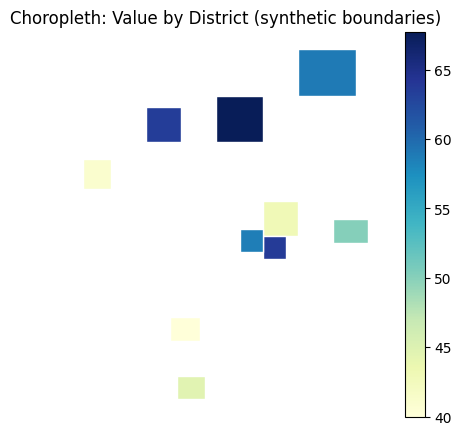

In [2]:
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt

admin = gpd.read_file("../../data/processed/admin_boundaries_synthetic.geojson")
latest = df[df["date"] == df["date"].max()]
merged = admin.merge(latest, left_on="pcode_sim", right_on="district_pcode")

fig, ax = plt.subplots(figsize=(6, 5))
merged.plot(column="value", cmap="YlGnBu", legend=True, edgecolor="white", ax=ax)
ax.set_title("Choropleth: Value by District (synthetic boundaries)")
ax.set_axis_off()

### Interactive version

In [3]:
import folium

# these are small illustrative rectangles, not real projected geometry —
# safe to silence the "geographic CRS" precision warning here
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    centroid = merged.geometry.centroid

m = folium.Map(location=[centroid.y.mean(), centroid.x.mean()], zoom_start=9, tiles="cartodbpositron")
map_layer = merged[["pcode_sim", "value", "geometry"]]  # drop non-JSON-serializable columns (e.g. dates)
folium.Choropleth(
    geo_data=map_layer, data=map_layer, columns=["pcode_sim", "value"],
    key_on="feature.properties.pcode_sim", fill_color="YlGnBu", legend_name="Value",
).add_to(m)
m

## Your turn

Join the dataset to the (synthetic) district boundary layer on P-codes; produce one choropleth and one bubble map in both languages, with a written justification of the chosen color scale. Then swap in the real HDX Rwanda COD-AB file (Chapter 3.2 of the course site) and re-run unchanged.

**Formative assessment.** Hands-on scripted exercise plus a data-quality note documenting any join failures caused by P-code mismatches.

## Responsible AI callback

A granular choropleth of a small population subgroup can itself be a re-identification or protection risk. This previews Module 6's data-minimization pattern and Module 9's formal governance treatment.